In [1]:
0

0

In [2]:
from transformers import GPT2LMHeadModel

/home/shamit/miniconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 503.56it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

These are the weights of gpt2 124M model, from hugging face, we will be trying to replicate them manually :)

In [5]:
import matplotlib.pyplot as plt

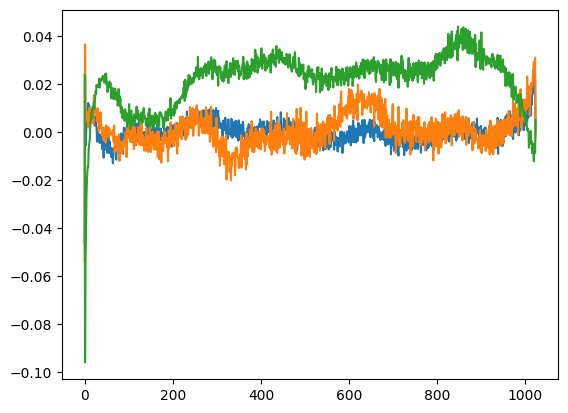

In [6]:
plt.plot(sd_hf['transformer.wpe.weight'][:,150])
plt.plot(sd_hf['transformer.wpe.weight'][:,200])
plt.plot(sd_hf['transformer.wpe.weight'][:,250])

Since the graph isnt smooth, we can say that the positional embeddings are bit jagged, ie we can say that model isnt trained properly...Like its not correlating any relation between different positions, which ideally should exits in a trained model.

In Attention is all you need paper, the positional embeddings were static and kept sinusoidal, but in gpt2 they are kept as trainable parametres.

Lets take this model for a spin

In [7]:
from transformers import pipeline, set_seed

generator = pipeline('text-generation', model='gpt2')

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 542.48it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
set_seed(42)
generator("Hello I am a language model", max_length=30, num_return_sequences=5)

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello I am a language model for the Internet that is already in use and I have created some interesting projects to bring it all to life. The Internet of Things will soon be accessible for anyone to use and everyone is welcome to experiment with it. I hope that it brings a lot of new people into the world and I hope that it does so in a way that doesn\'t compromise the freedom of the Internet.\n\nI have a number of projects I am working on that I will bring to light soon. I started working on a project called "AeroLocker" that allowed you to "lock" the computer and not the data inside. I will be presenting a demo of this in the coming weeks.\n\nI think the real potential for a lot of things to come is probably in the software. The IoT will be really important and we shouldn\'t forget that. I think we should be looking at something that is not just hardware but also some kind of infrastructure for things like that to work. And I think there will be a lot of possibil